# 04 Evaluated Pricing

This notebook combines Treasury discounting with peer-implied fair spreads to generate model prices, residuals, and review flags.

At this point the workflow starts to look like an operational pricing process. The main output is not just a model price. It is a comparison between observed levels and fair-value levels, along with a reason to escalate or not escalate a bond for review.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt

from src.evaluator import build_evaluation_outputs

In [3]:
evaluation_table, comp_table = build_evaluation_outputs(
    analytics_path=PROJECT_ROOT / "outputs" / "bond_analytics.csv",
    bond_universe_path=PROJECT_ROOT / "data" / "raw" / "bond_universe.csv",
    treasury_curve_path=PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv",
    max_comps=3,
)
evaluation_table

,bond_id,issuer,evaluation_date,maturity_date,coupon_rate,clean_price,accrued_interest,dirty_price,ytm,spread_to_curve,...,face_value,fair_spread,comp_count,comp_support_score,comp_ids,fair_model_dirty_price,price_residual,spread_residual_bps,review_flag,review_reason
0,GE_1994_650,GE,1991-03-14,1994-03-01,0.0650,100.11,0.229620,100.339620,0.064553,-0.007052,...,100,-0.007134,3,3.276123,"GE_1998_725, IBM_1993_625, XOM_1997_710",100.362293,-0.022673,0.819363,Normal,within tolerance
1,GE_1998_725,GE,1991-03-14,1998-11-15,0.0725,99.74,2.383287,102.123287,0.072895,-0.005841,...,100,-0.007367,3,3.100957,"GE_1994_650, XOM_1997_710, IBM_1996_700",103.046896,-0.923608,15.259302,Review,moderate spread residual; moderate price residual
2,IBM_1993_625,IBM,1991-03-14,1993-06-15,0.0625,100.42,1.528159,101.948159,0.060409,-0.009434,...,100,-0.008702,3,3.338003,"IBM_1996_700, GE_1994_650, JNJ_1995_675",101.789362,0.158798,-7.325416,Normal,within tolerance
3,IBM_1996_700,IBM,1991-03-14,1996-09-15,0.0700,101.18,3.480663,104.660663,0.067324,-0.009468,...,100,-0.008165,3,3.789177,"IBM_1993_625, XOM_1997_710, GE_1998_725",104.042091,0.618572,-13.037852,Review,moderate spread residual; moderate price residual
4,JNJ_1995_675,JNJ,1991-03-14,1995-08-01,0.0675,100.67,0.764503,101.434503,0.065740,-0.008968,...,100,-0.006308,3,2.067624,"JNJ_2000_740, IBM_1996_700, GE_1994_650",100.397115,1.037388,-26.603716,High Review,large spread residual; large price residual
5,JNJ_2000_740,JNJ,1991-03-14,2000-05-15,0.0740,99.92,2.432597,102.352597,0.074089,-0.005196,...,100,-0.008225,3,1.771197,"JNJ_1995_675, GE_1998_725, XOM_2001_760",104.446233,-2.093636,30.285345,High Review,large spread residual; large price residual
6,XOM_1997_710,XOM,1991-03-14,1997-02-15,0.0710,100.23,0.529558,100.759558,0.070487,-0.006754,...,100,-0.005379,3,3.303057,"XOM_2001_760, IBM_1996_700, GE_1998_725",100.078558,0.681000,-13.751412,Review,moderate spread residual; moderate price residual
7,XOM_2001_760,XOM,1991-03-14,2001-12-01,0.0760,99.35,2.150549,101.500549,0.076864,-0.001546,...,100,-0.006599,3,1.507743,"XOM_1997_710, GE_1998_725, JNJ_2000_740",105.360746,-3.860197,50.528346,High Review,large spread residual; large price residual


In [4]:
evaluation_view = evaluation_table[
    [
        "bond_id",
        "dirty_price",
        "spread_to_curve",
        "fair_spread",
        "fair_model_dirty_price",
        "price_residual",
        "spread_residual_bps",
        "review_flag",
    ]
].copy()
evaluation_view[["spread_to_curve", "fair_spread"]] = evaluation_view[["spread_to_curve", "fair_spread"]] * 10000
evaluation_view

,bond_id,dirty_price,spread_to_curve,fair_spread,fair_model_dirty_price,price_residual,spread_residual_bps,review_flag
0,GE_1994_650,100.339620,-70.516929,-71.336292,100.362293,-0.022673,0.819363,Normal
1,GE_1998_725,102.123287,-58.413883,-73.673185,103.046896,-0.923608,15.259302,Review
2,IBM_1993_625,101.948159,-94.341272,-87.015856,101.789362,0.158798,-7.325416,Normal
3,IBM_1996_700,104.660663,-94.684358,-81.646507,104.042091,0.618572,-13.037852,Review
4,JNJ_1995_675,101.434503,-89.681757,-63.078040,100.397115,1.037388,-26.603716,High Review
5,JNJ_2000_740,102.352597,-51.963955,-82.249300,104.446233,-2.093636,30.285345,High Review
6,XOM_1997_710,100.759558,-67.538222,-53.786811,100.078558,0.681000,-13.751412,Review
7,XOM_2001_760,101.500549,-15.464463,-65.992809,105.360746,-3.860197,50.528346,High Review


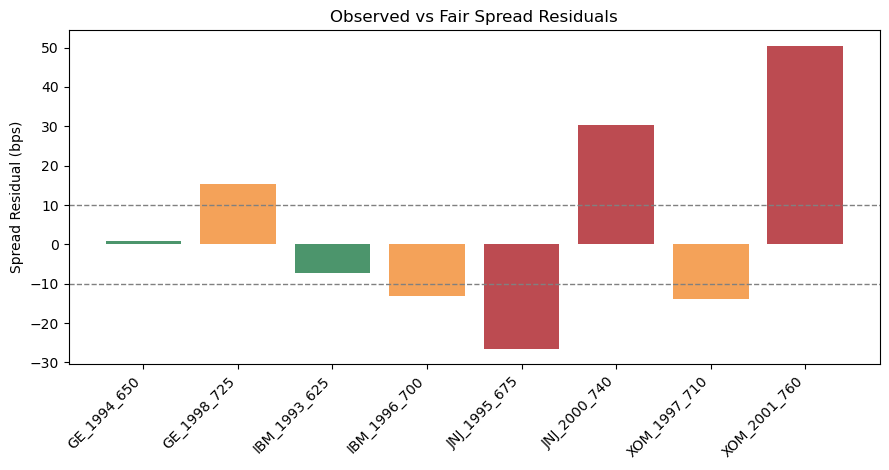

In [5]:
colors = {"Normal": "#4C956C", "Review": "#F4A259", "High Review": "#BC4B51"}
plt.figure(figsize=(9, 4.8))
plt.bar(
    evaluation_table["bond_id"],
    evaluation_table["spread_residual_bps"],
    color=[colors.get(flag, "#577590") for flag in evaluation_table["review_flag"]],
)
plt.axhline(10, linestyle="--", linewidth=1, color="gray")
plt.axhline(-10, linestyle="--", linewidth=1, color="gray")
plt.ylabel("Spread Residual (bps)")
plt.title("Observed vs Fair Spread Residuals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [6]:
comp_table[["target_bond_id", "comp_bond_id", "comp_score", "comp_weight", "fair_spread"]]

,target_bond_id,comp_bond_id,comp_score,comp_weight,fair_spread
0,GE_1994_650,GE_1998_725,4.994626,4.994626,-0.007134
1,GE_1994_650,IBM_1993_625,3.092987,3.092987,-0.007134
2,GE_1994_650,XOM_1997_710,1.740755,1.740755,-0.007134
3,GE_1998_725,GE_1994_650,4.994626,4.994626,-0.007367
4,GE_1998_725,XOM_1997_710,2.753871,2.753871,-0.007367
5,GE_1998_725,IBM_1996_700,1.554374,1.554374,-0.007367
6,IBM_1993_625,IBM_1996_700,6.512654,6.512654,-0.008702
7,IBM_1993_625,GE_1994_650,3.092987,3.092987,-0.008702
8,IBM_1993_625,JNJ_1995_675,0.408366,0.408366,-0.008702
9,IBM_1996_700,IBM_1993_625,6.512654,6.512654,-0.008165


A flagged bond here does not automatically mean the observed price is wrong. It means the bond deserves attention because the observed level is meaningfully different from the peer-supported fair level or because the peer support itself is not strong enough to be fully comfortable.